In [28]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import dtale
from ydata_profiling import ProfileReport

sns.set_style('darkgrid')

In [29]:
df = pd.read_csv("./data/gios_daily_agg.csv")
df

,date,PM10,PM25,SO2,CO,NO2,O3
0,2020-01-01,20.48,15.73,19.71,0.32,36.37,64.26
1,2020-01-02,77.82,68.60,15.17,1.17,62.94,34.55
2,2020-01-03,60.62,54.66,14.33,1.24,54.66,40.25
3,2020-01-04,9.73,6.76,4.26,0.29,14.91,67.12
4,2020-01-05,13.55,10.24,5.34,0.34,49.86,71.36
...,...,...,...,...,...,...,...
2278,2026-03-28,22.77,16.70,4.70,0.37,29.80,72.71
2279,2026-03-29,17.73,14.76,4.10,0.38,20.80,70.05
2280,2026-03-30,21.10,13.77,11.50,0.37,27.90,65.57
2281,2026-03-31,19.04,13.28,6.00,0.37,41.30,63.02


In [30]:
df["date"] = pd.to_datetime(df["date"])
df = df.set_index('date')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2283 entries, 2020-01-01 to 2026-04-01
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM10    2171 non-null   float64
 1   PM25    2240 non-null   float64
 2   SO2     2228 non-null   float64
 3   CO      2250 non-null   float64
 4   NO2     2240 non-null   float64
 5   O3      2233 non-null   float64
dtypes: float64(6)
memory usage: 124.9 KB


In [32]:
df.dtypes

PM10    float64
PM25    float64
SO2     float64
CO      float64
NO2     float64
O3      float64
dtype: object

In [33]:
na_counts = df.isna().sum()
total_na = df.isna().sum().sum()

print(na_counts)
print(f'\nTotal: {total_na}')

PM10    112
PM25     43
SO2      55
CO       33
NO2      43
O3       50
dtype: int64

Total: 336


In [34]:
mask = (df['PM10'] < df['PM25']) & df['PM10'].notna() & df['PM25'].notna()
df.loc[mask, 'PM10'] = np.nan

In [35]:
na_counts = df.isna().sum()
total_na = df.isna().sum().sum()

print(na_counts)
print(f'\nTotal: {total_na}')

PM10    135
PM25     43
SO2      55
CO       33
NO2      43
O3       50
dtype: int64

Total: 359


In [36]:
import pandas as pd
from sklearn.linear_model import LinearRegression


SHORT_GAP = 3
MEDIUM_GAP = 14
POLLUTANTS = ["PM10", "PM25", "SO2", "CO", "NO2", "O3"]

# df = df.set_index("date")
df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq="D"))
df.index.name = "date"


def gap_lengths(series):
    mask = series.isna()
    groups = (mask != mask.shift()).cumsum()
    lengths = pd.Series(0, index=series.index)
    for g, idx in series[mask].groupby(groups[mask]).groups.items():
        lengths.loc[idx] = len(idx)
    return lengths


def seasonal_median(series, mask):
    out = series.copy()
    lookup = series.dropna().groupby(series.dropna().index.dayofyear).median()
    doys = out.index[mask].dayofyear.map(lambda d: 59 if d == 60 else d)
    out.loc[mask] = doys.map(lookup).values
    return out


def regression_impute(df_full, target, predictors):
    train = df_full[[target] + predictors].dropna()
    if len(train) < 2:
        out = df_full[target].copy()
        return out.fillna(out.median())
    model = LinearRegression().fit(train[predictors].values, train[target].values)
    out = df_full[target].copy()
    missing = out.isna() & df_full[predictors].notna().all(axis=1)
    if missing.any():
        out[missing] = model.predict(df_full.loc[missing, predictors].values)
    return out



predictors_map = {
    "PM10": ["PM25"], "PM25": ["PM10"],
    "SO2": ["PM10", "PM25"], "CO": ["PM25", "NO2"],
    "NO2": ["CO", "PM10"], "O3": ["NO2", "PM25"],
}

for col in POLLUTANTS:
    lens = gap_lengths(df[col])
    medium_mask = df[col].isna() & (lens > SHORT_GAP) & (lens <= MEDIUM_GAP)
    df[col] = df[col].interpolate(method="linear", limit=SHORT_GAP, limit_area="inside")
    if medium_mask.any():
        df[col] = seasonal_median(df[col], medium_mask & df[col].isna())

for col in POLLUTANTS:
    if df[col].isna().any():
        df[col] = regression_impute(df, col, predictors_map[col])

for col in POLLUTANTS:
    if df[col].isna().any():
        df[col] = seasonal_median(df[col], df[col].isna())

In [38]:
na_counts = df.isna().sum()
total_na = df.isna().sum().sum()

print(na_counts)
print(f'\nTotal: {total_na}')

PM10    0
PM25    0
SO2     0
CO      0
NO2     0
O3      0
dtype: int64

Total: 0


In [9]:
# profile = ProfileReport(df, explorative=True)
# profile.to_file("./auto_report/ydata-profiling_report.html") 

In [10]:
# profile = ProfileReport(
#     df,
#     tsmode=True,
#     sortby="date",
#     vars={"timeseries": {"pacf_acf_lag": 365, "significance_threshold": 0.05}}
# )

# profile.to_file("./auto_report/ydata-profiling_timeseries_report.html")

In [39]:
df.describe(include='float64').T

,count,mean,std,min,25%,50%,75%,max
PM10,2283.0,24.102838,14.408938,3.43,14.835,20.04,28.835,155.33
PM25,2283.0,16.780127,12.426021,2.97,8.890,12.78,20.175,142.57
SO2,2283.0,9.922651,10.241200,0.42,5.435,7.20,10.100,121.90
CO,2283.0,1.916304,6.910365,0.21,0.370,0.50,0.810,139.62
NO2,2283.0,41.746907,21.206481,3.19,26.850,38.55,52.770,165.31
O3,2283.0,70.689949,31.142706,2.24,47.705,69.95,93.065,171.30


In [40]:
numeric_cols = df.select_dtypes(include=['float64']).columns.tolist()
n_cols = len(numeric_cols)

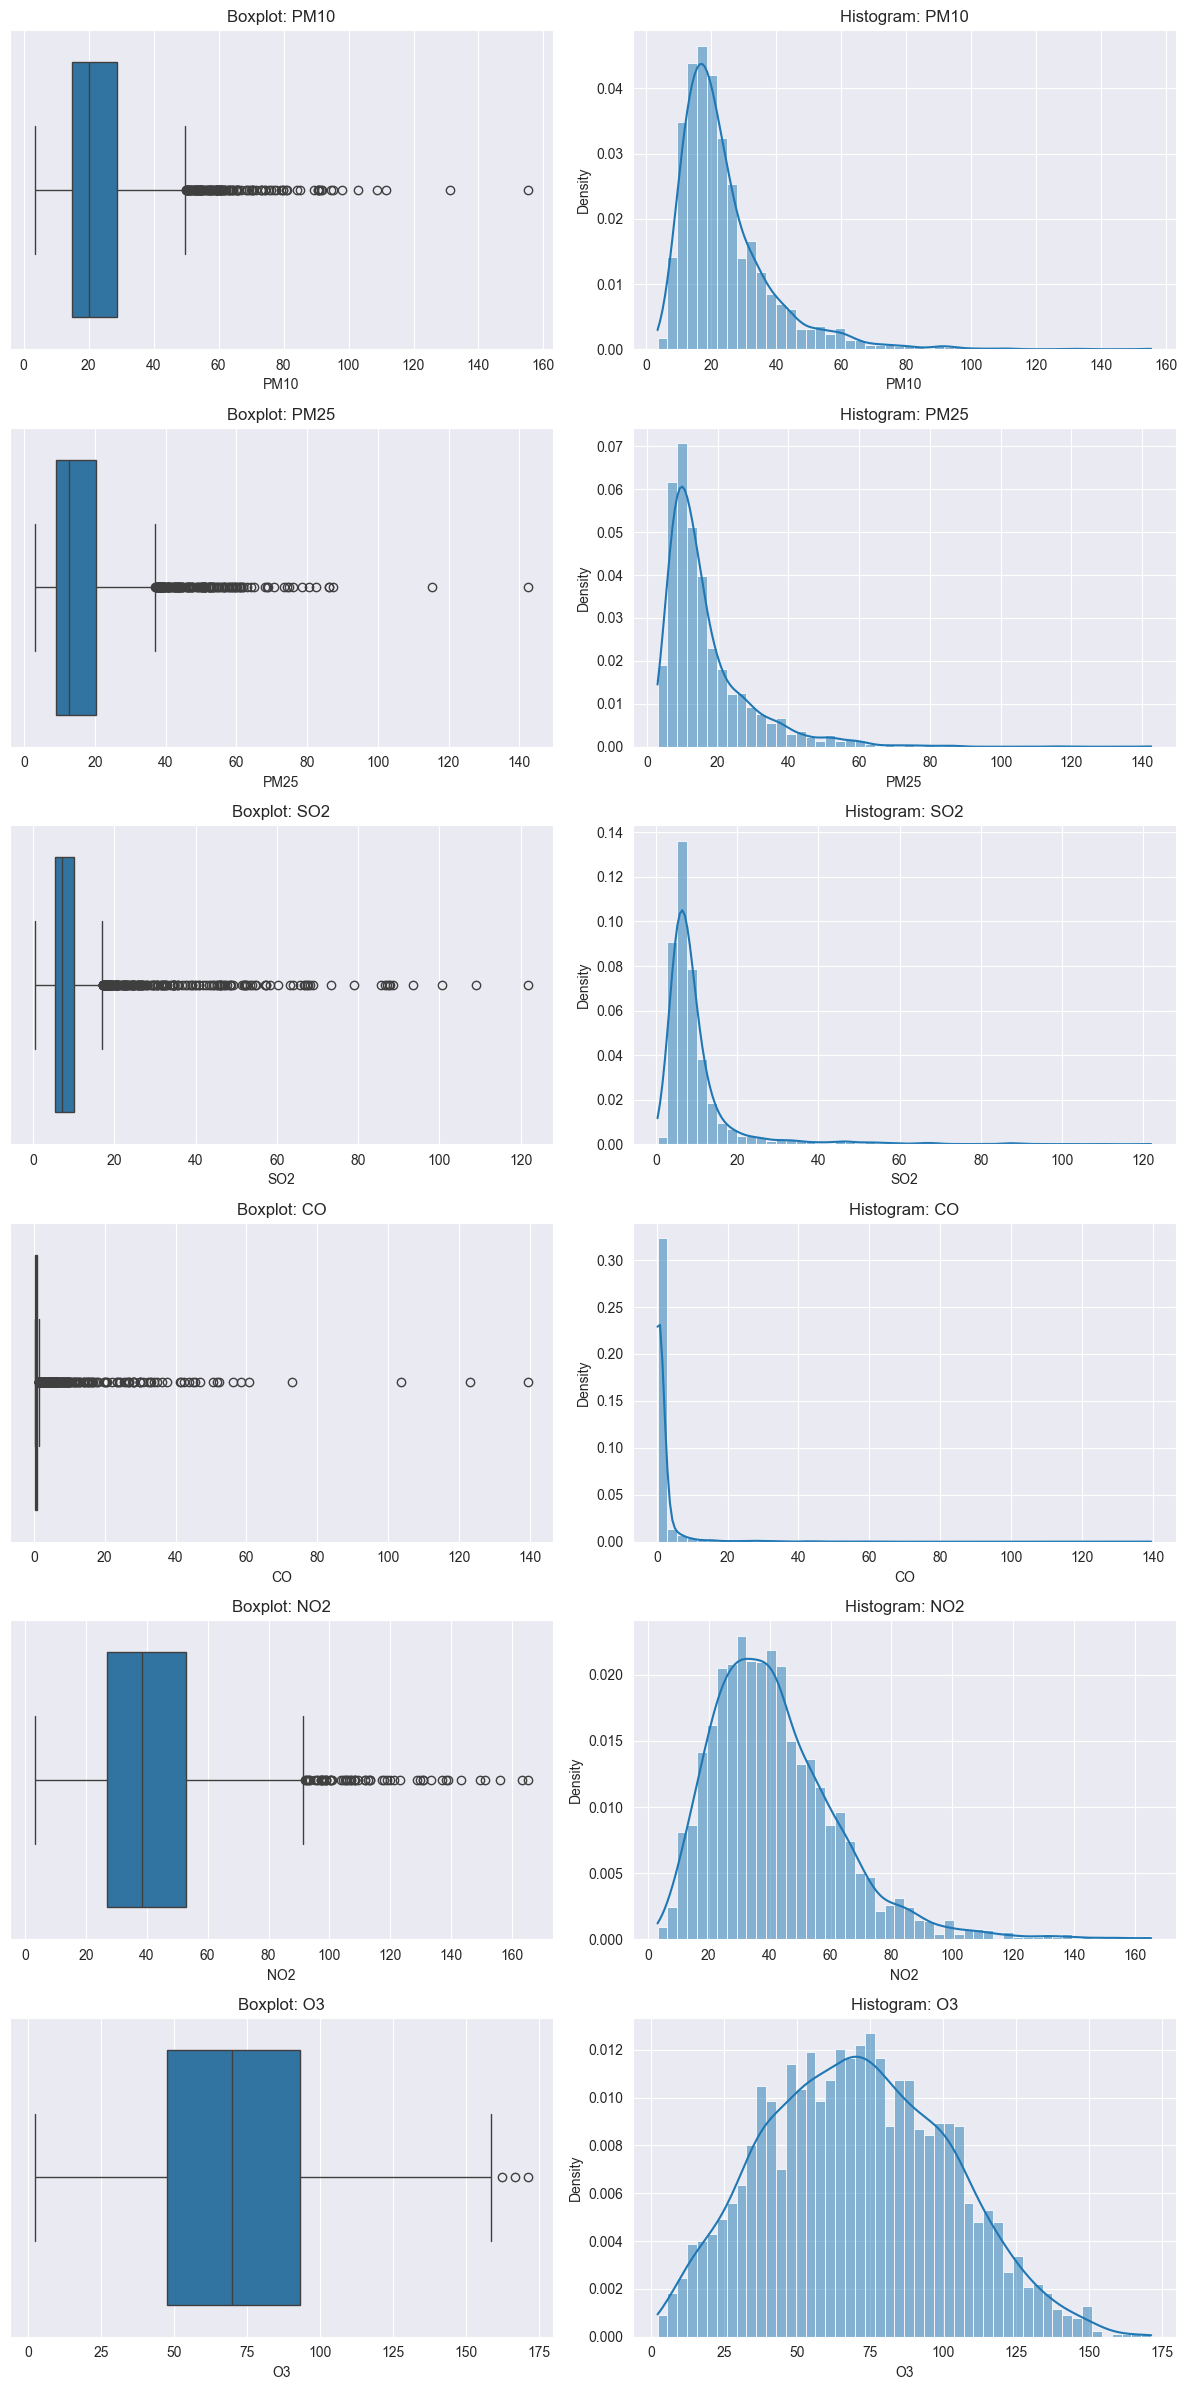

In [41]:
fig, axes = plt.subplots(nrows=n_cols, ncols=2, figsize=(12, 4 * n_cols))

for i, col in enumerate(numeric_cols):
    
    sns.boxplot(x=df[col], ax=axes[i][0])
    axes[i][0].set_title(f'Boxplot: {col}')
    
    sns.histplot(data=df, x=col, ax=axes[i][1], kde=True, bins=50, stat="density")
    axes[i][1].set_title(f'Histogram: {col}')

plt.tight_layout()
plt.show()

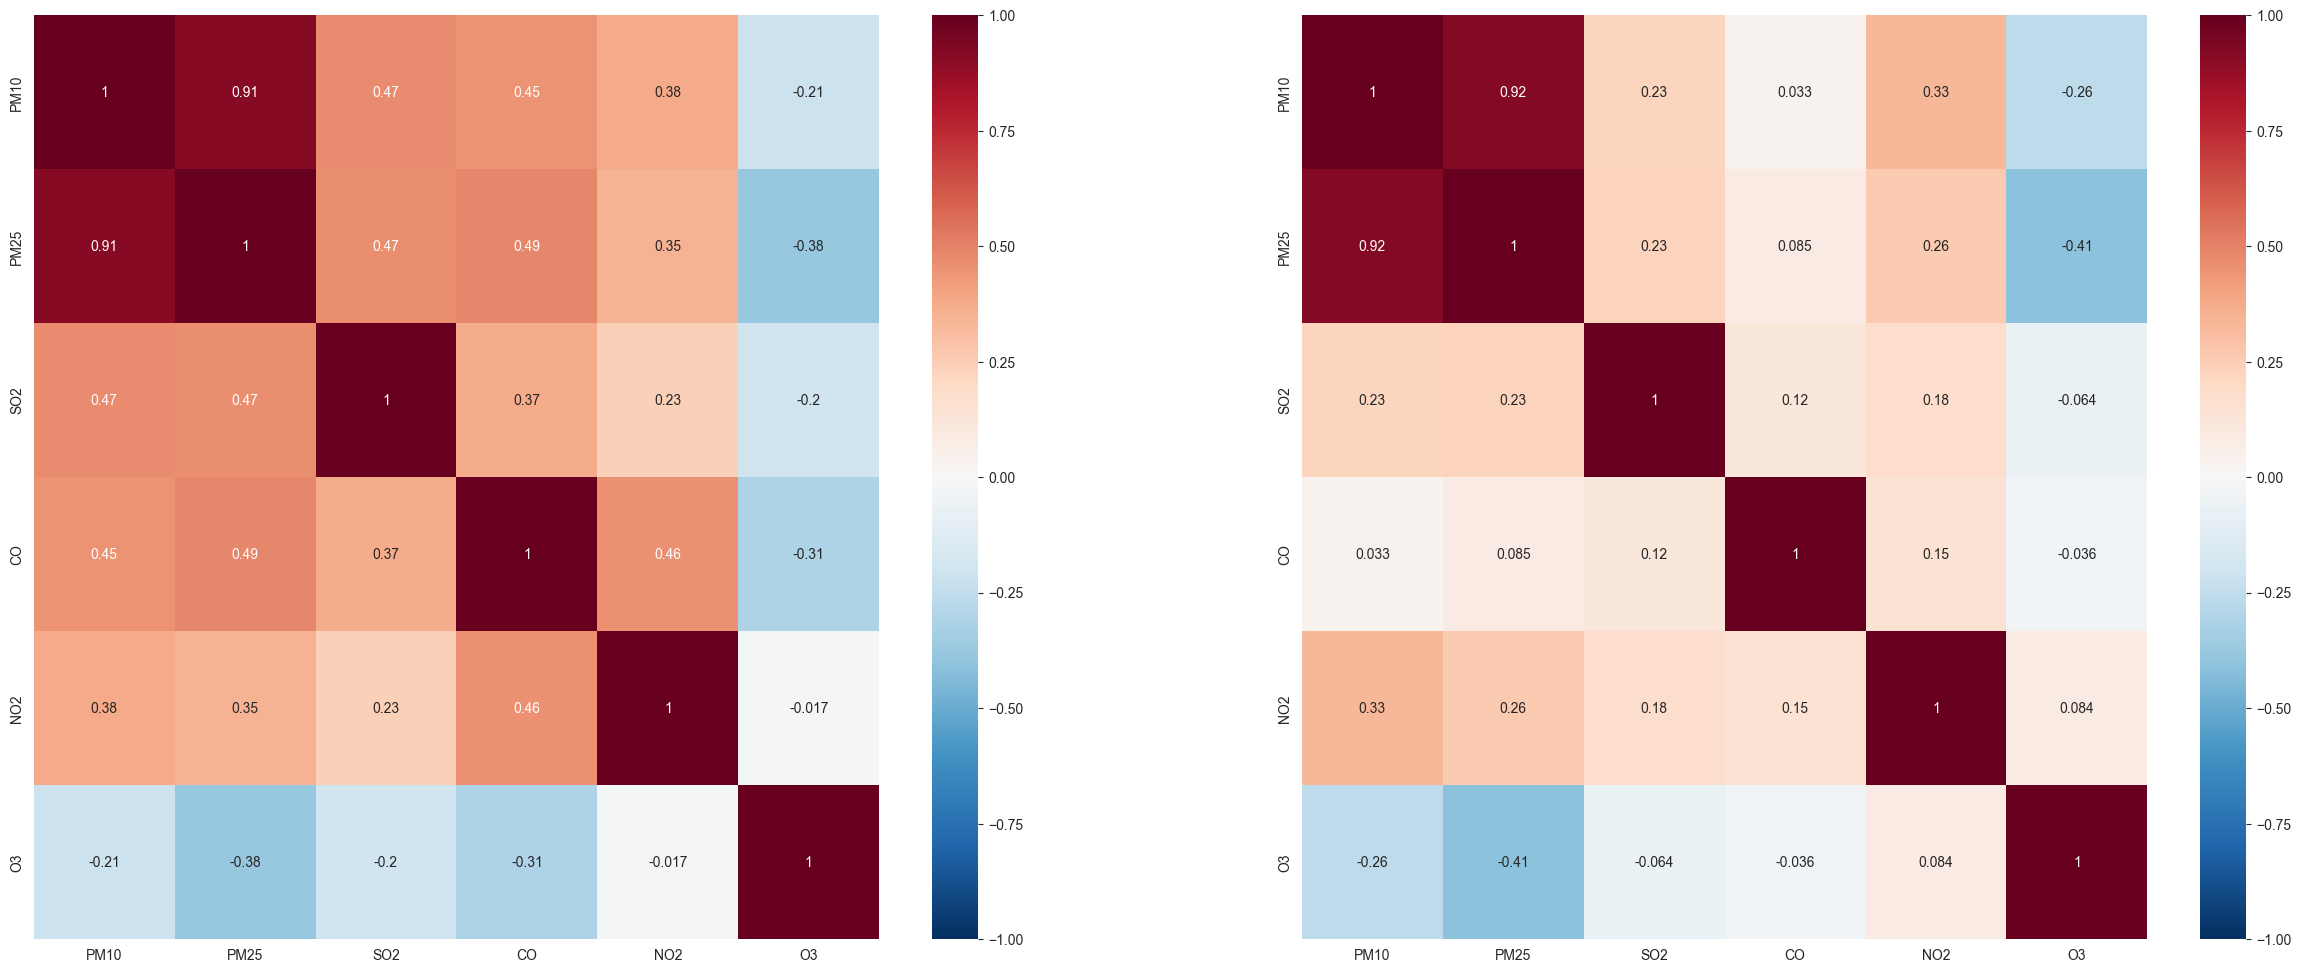

In [42]:
corr_pearson = df.corr(method='pearson')
corr_spearman = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(30, 12))
sns.heatmap(corr_spearman, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[0])
sns.heatmap(corr_pearson, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", center=0, ax=axes[1])
plt.show()

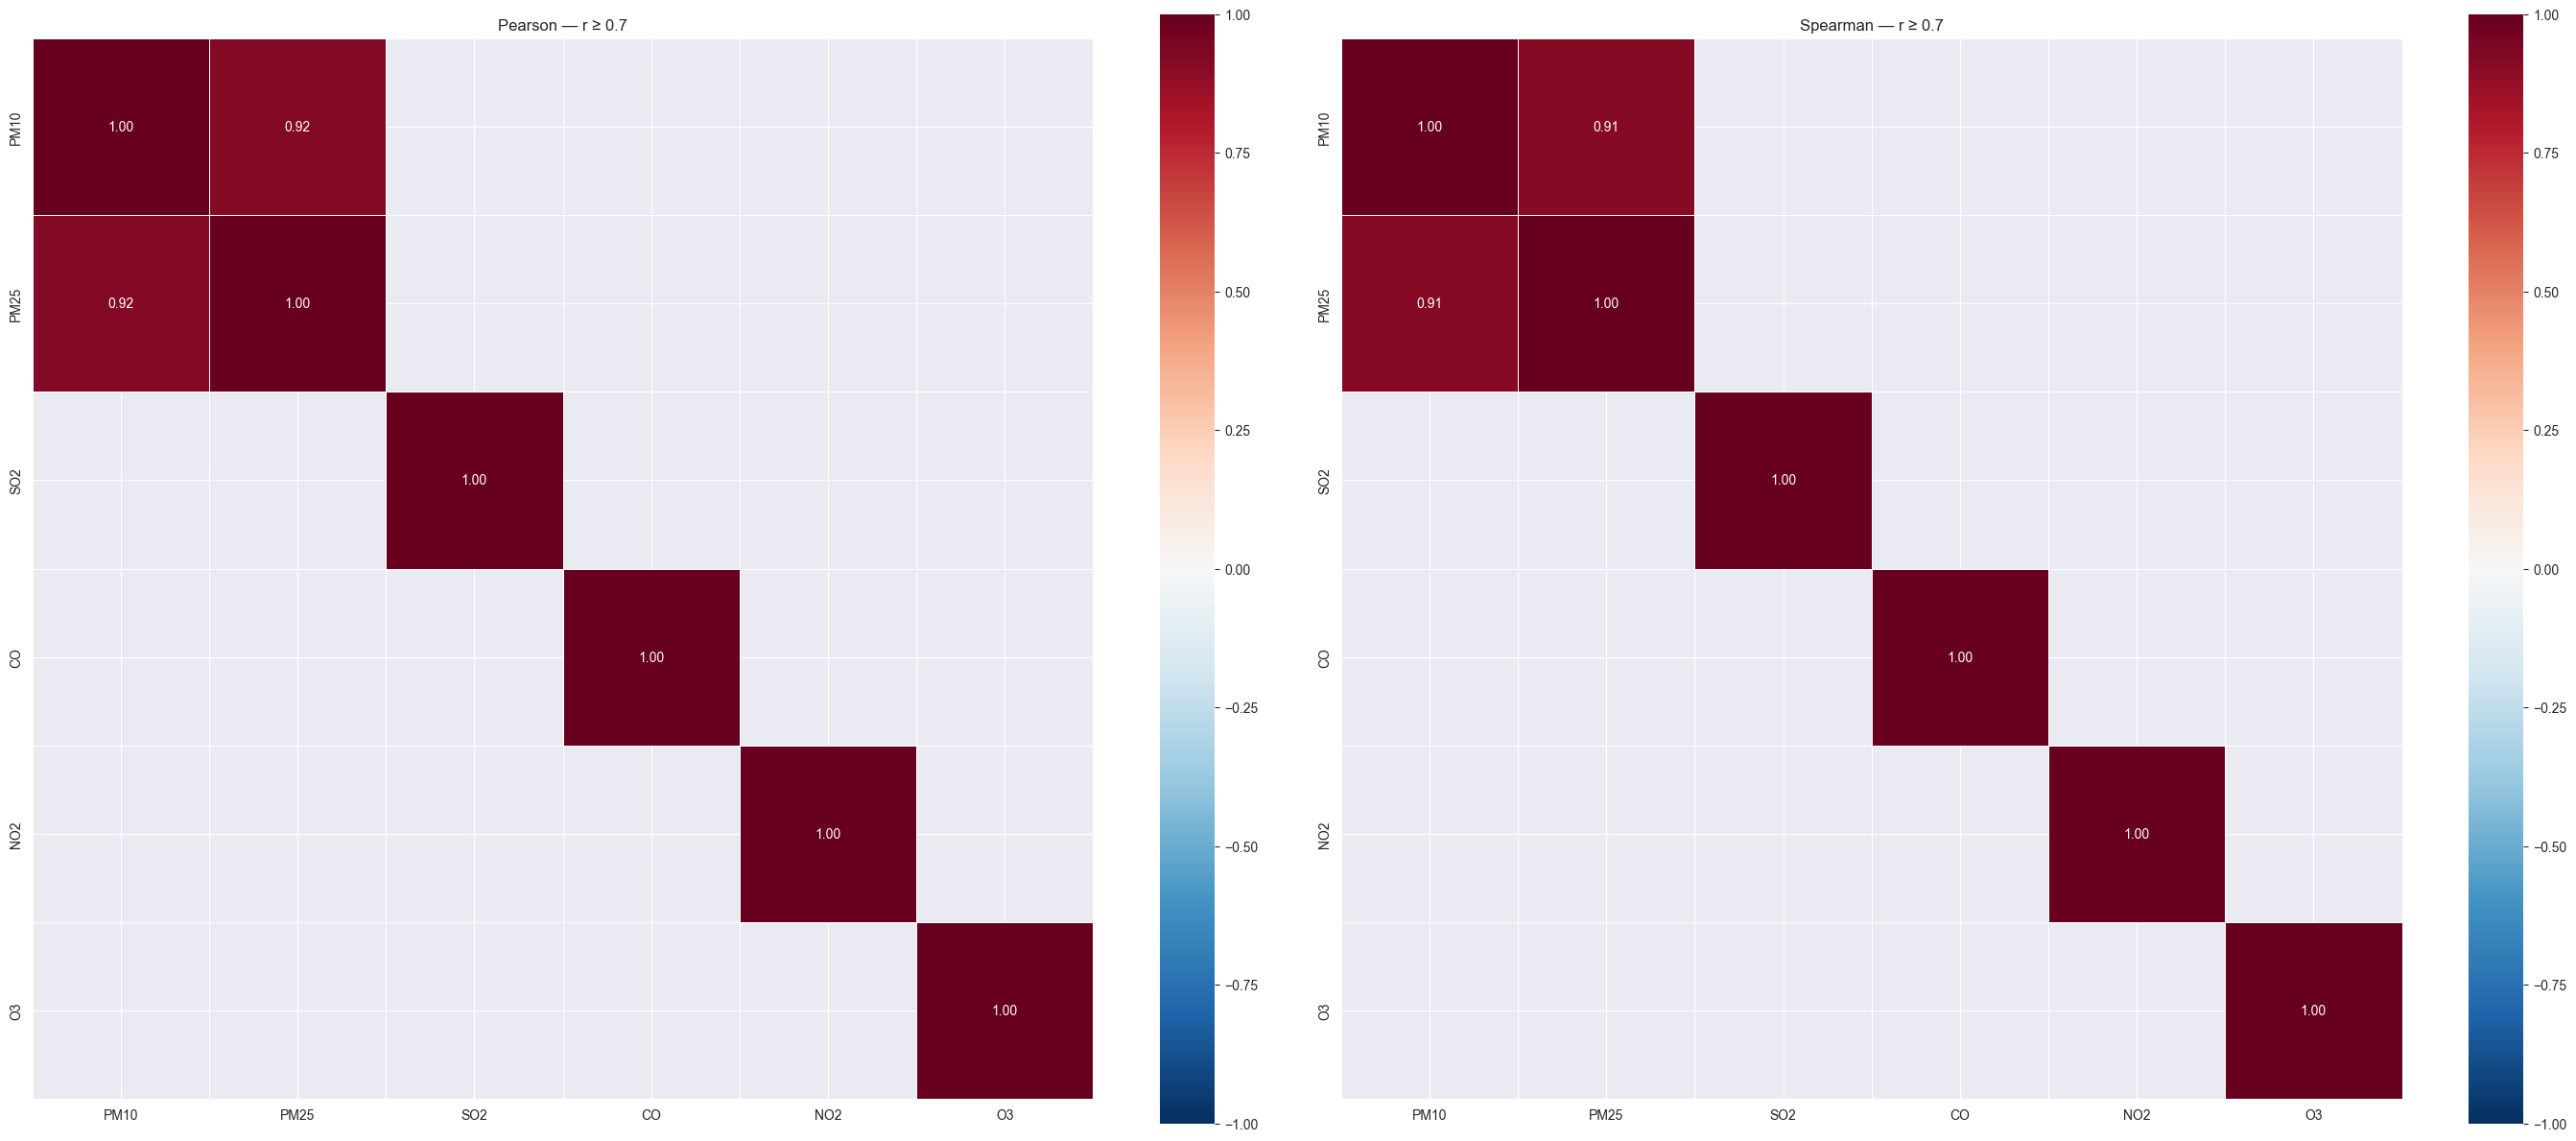

In [43]:
r_df_p = df.corr(method='pearson')
r_df_s = df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

sns.heatmap(r_df_p, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_p.abs() < 0.7,
            square=True, linewidths=0.5,
            ax=axes[0])
axes[0].set_title('Pearson — r ≥ 0.7')

sns.heatmap(r_df_s, annot=True, fmt='.2f',
            vmin=-1, vmax=1, cmap="RdBu_r", center=0,
            mask=r_df_s.abs() < 0.7,
            square=True, linewidths=0.5,
            ax=axes[1])
axes[1].set_title('Spearman — r ≥ 0.7')

plt.tight_layout()
plt.show()

PM10 <-> PM2.5: r = 0,92 — ogromna współliniowość. W modelu VAR ta para praktycznie niesie tę samą informację

In [44]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


X = df
X_with_const = add_constant(X)   

vif = pd.DataFrame({
    'variable': X_with_const.columns,
    'VIF': [variance_inflation_factor(X_with_const.values, i) 
            for i in range(X_with_const.shape[1])]
})

vif = vif[vif['variable'] != 'const'].sort_values('VIF', ascending=False)
print(vif)

  variable       VIF
2     PM25  8.490187
1     PM10  7.800485
6       O3  1.384885
5      NO2  1.212691
3      SO2  1.082047
4       CO  1.058080


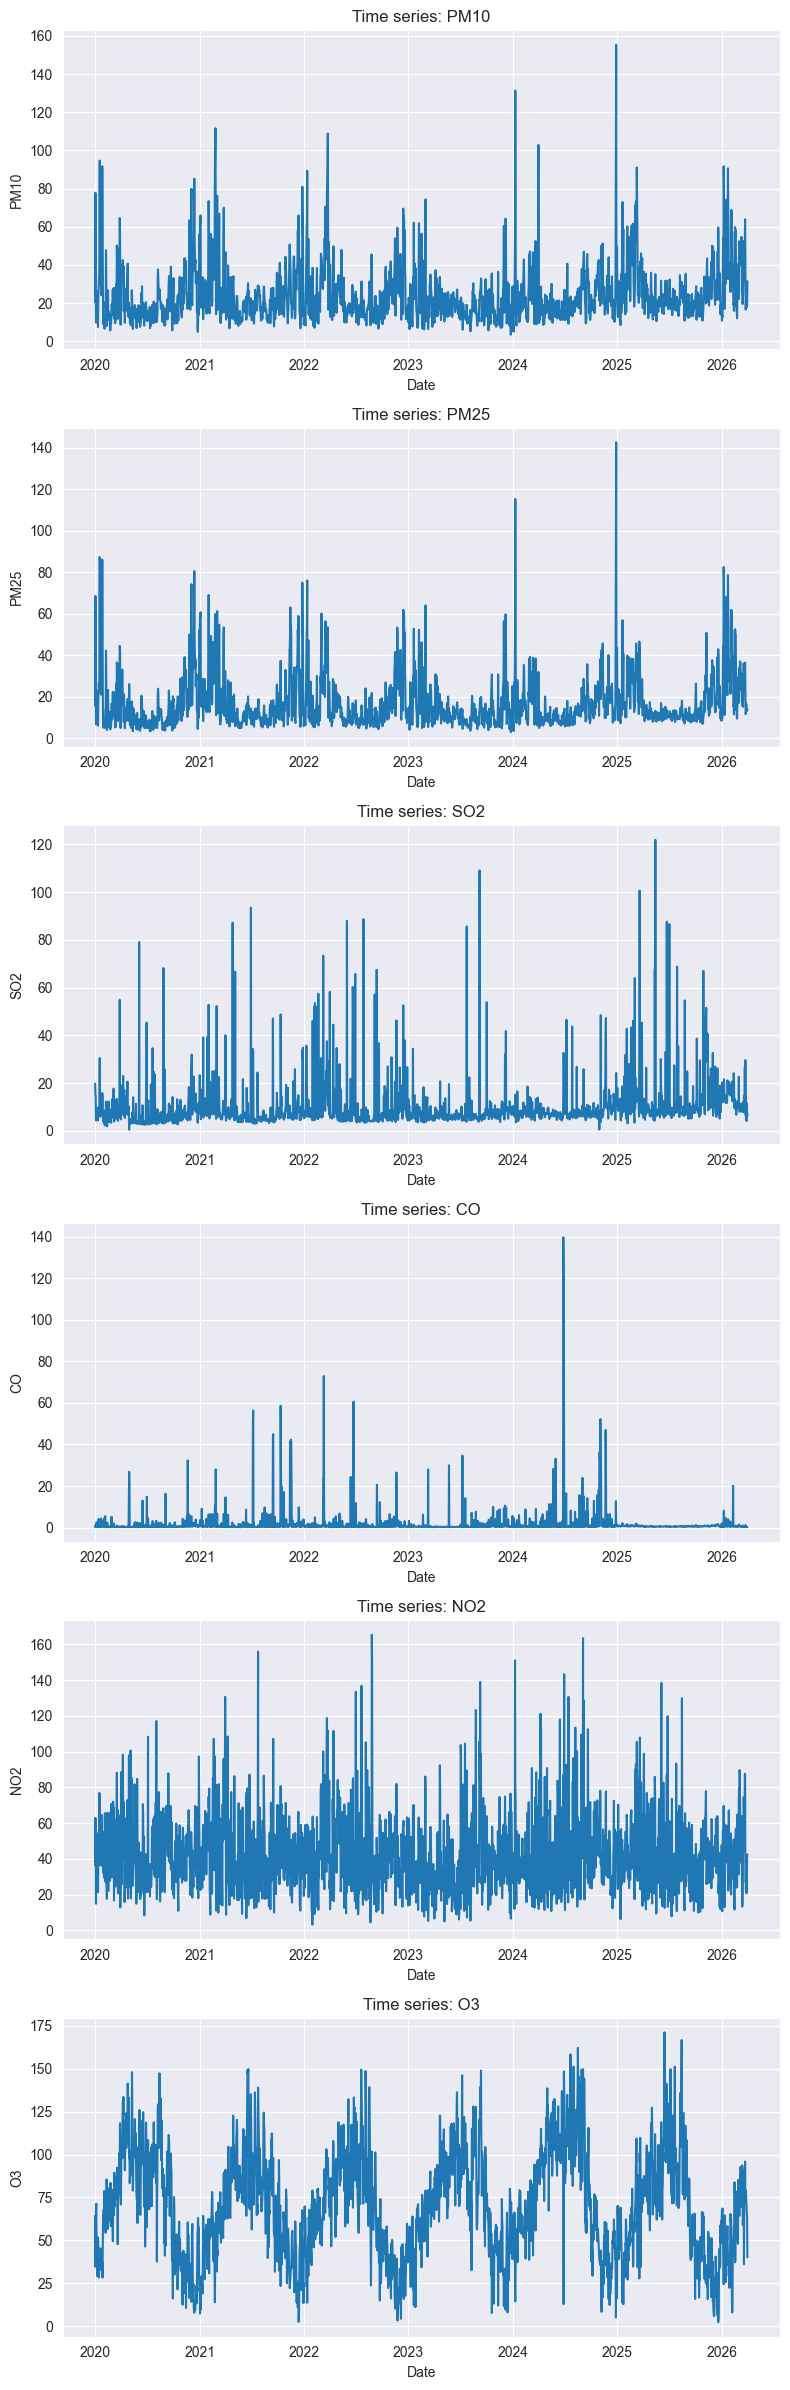

In [45]:
fig, axes = plt.subplots(nrows=n_cols, ncols=1, figsize=(8, 4 * n_cols))

for i, col in enumerate(numeric_cols):
    sns.lineplot(data=df, x='date', y=col, ax=axes[i])
    axes[i].set_title(f'Time series: {col}')
    axes[i].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [46]:
# fig, axes = plt.subplots(nrows=n_cols, ncols=2, figsize=(10, 3 * n_cols), squeeze=False)

# for i, col in enumerate(numeric_cols):
#     plot_acf(df[col].dropna(), lags=60, adjusted=True, ax=axes[i][0]) 
#     plot_pacf(df[col].dropna(), lags=60, method='ywm', ax=axes[i][1]) 
#     axes[i][0].set_title(f'{col}')
#     axes[i][1].set_title(f'{col}')

# plt.tight_layout()
# plt.show()


In [65]:
df['Year'] = df.index.year
df['Month'] = df.index.month_name()
df['DayOfWeek'] = df.index.day_name()
# tydzien , dzizien roboczy i nie
# dummies do tygodniowych

In [66]:
num_cols = df.select_dtypes(include=['float64']).columns.tolist()
num_cols

['PM10', 'PM25', 'SO2', 'CO', 'NO2', 'O3']

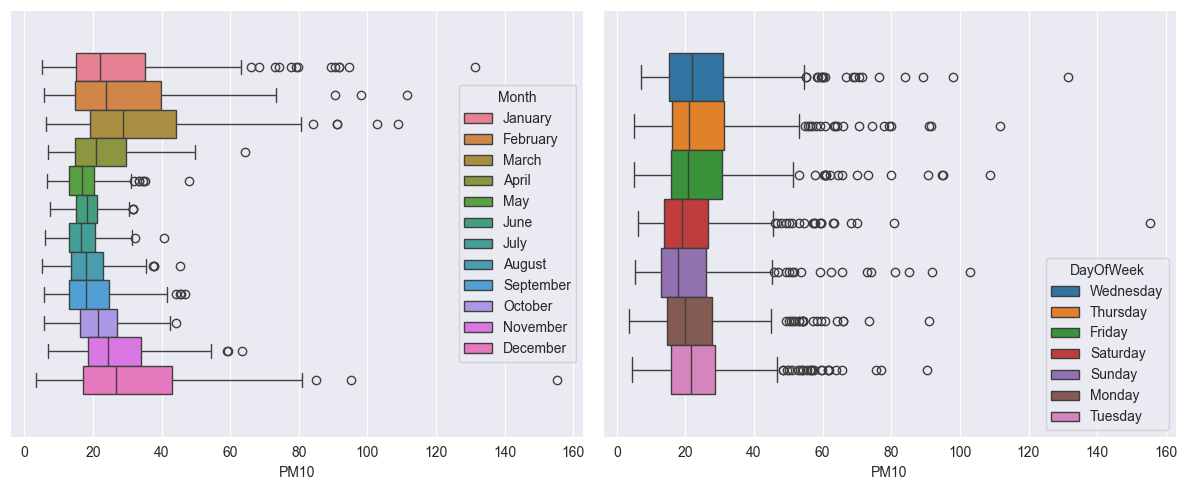

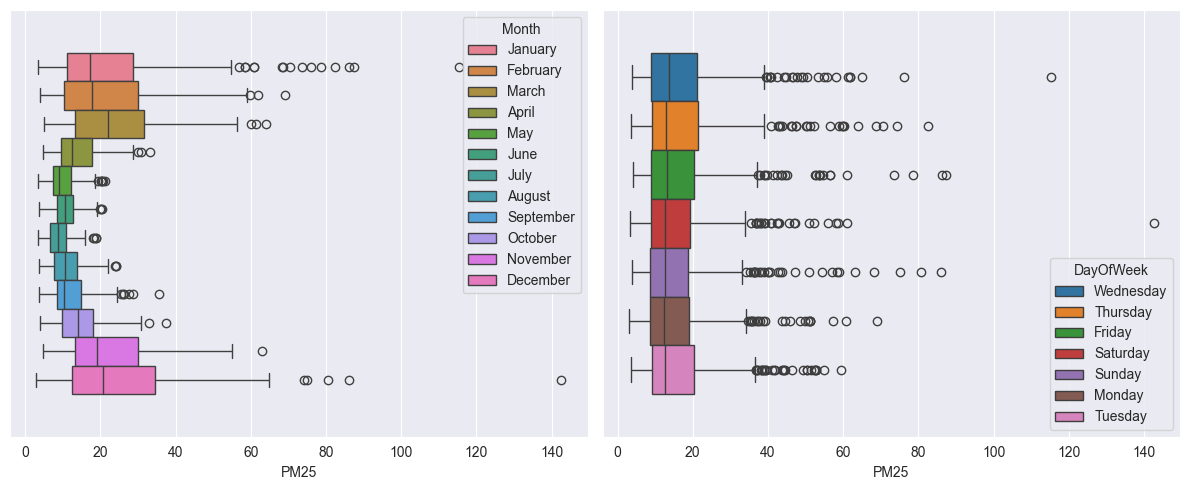

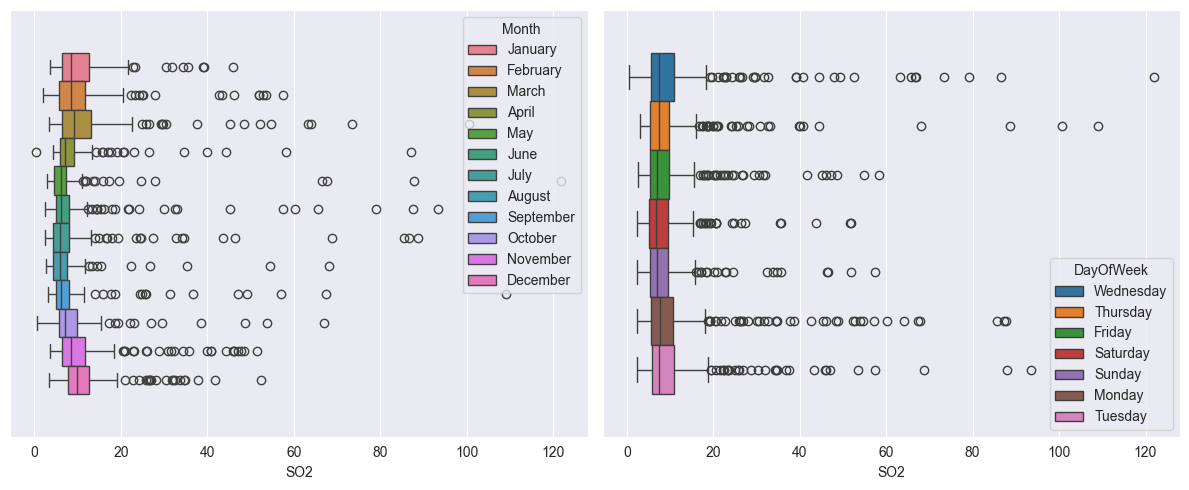

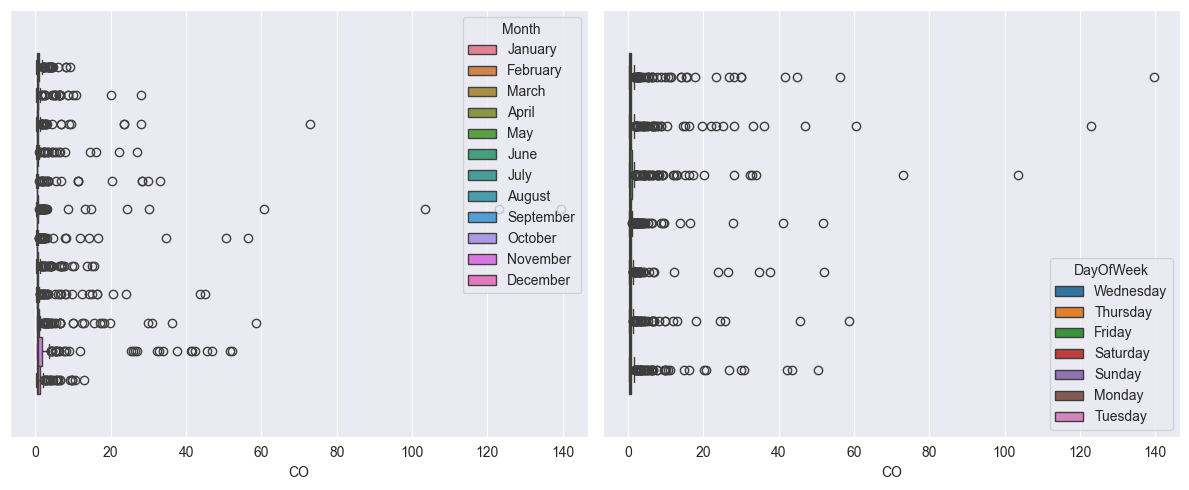

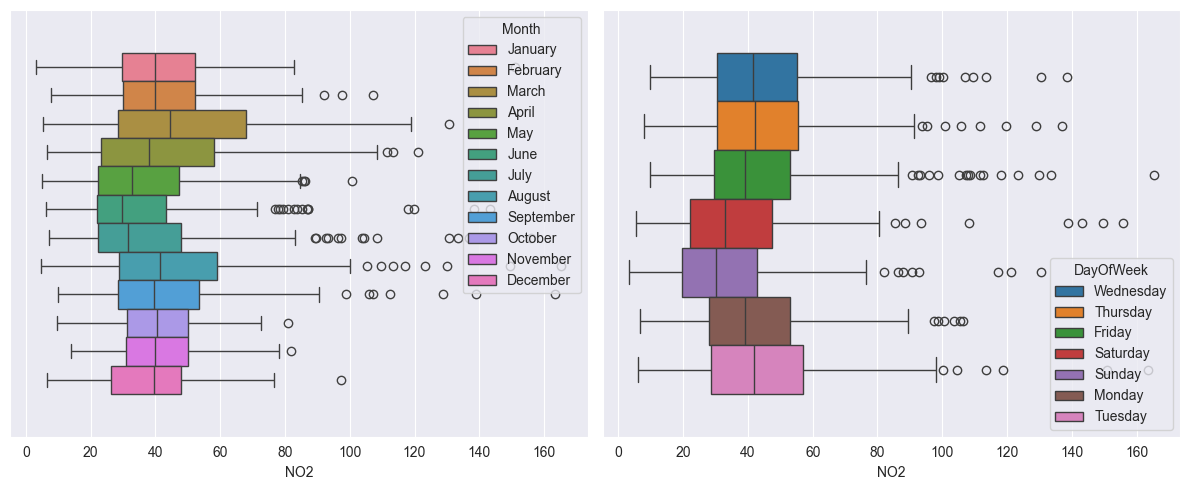

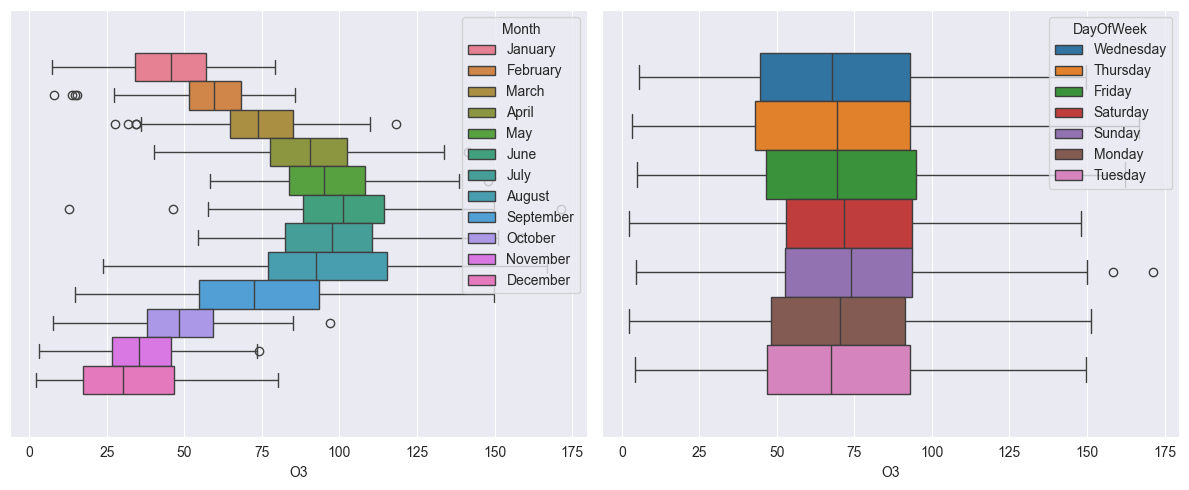

In [67]:
for i, col in enumerate(num_cols):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    sns.boxplot(data=df, x=col, hue=X['Month'], ax=axes[0])
    sns.boxplot(data=df, x=col, hue=X['DayOfWeek'], ax=axes[1])
    plt.xlabel(f'{col}')
    # plt.ylabel('Month')
    plt.tight_layout()
    plt.show()

In [68]:
heating_months = ['October', 'November', 'December', 'January', 'February','March']
df['Season'] = df['Month'].isin(heating_months).map({True: 'Heating', False: 'Non-Heating'})

working_days = ['Monday', 'Tuesday', 'Wednesday' 'Thursday', 'Friday']
df['Workind_day'] = df['DayOfWeek'].isin(working_days).map({True: 'working-day', False: 'weekend'})

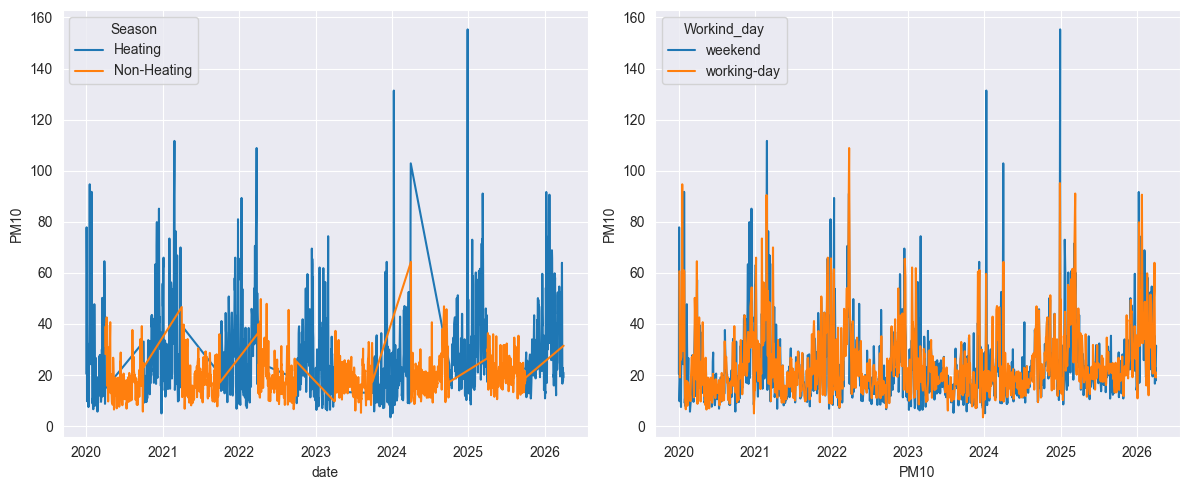

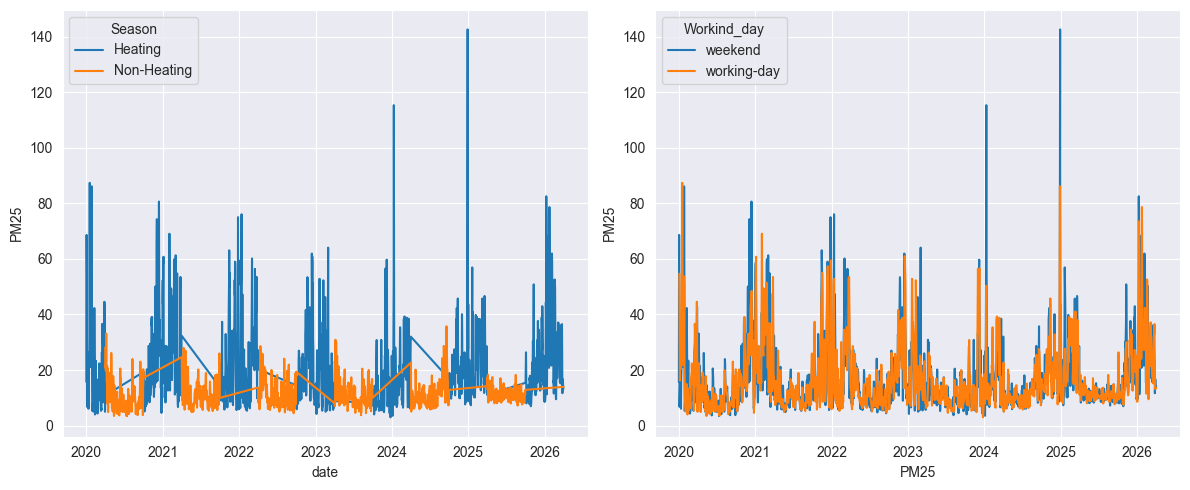

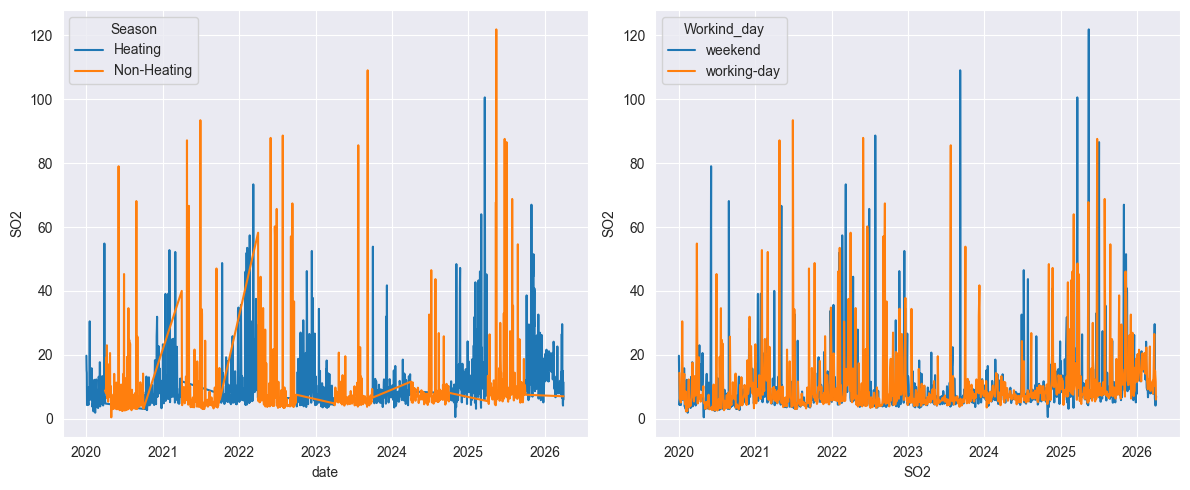

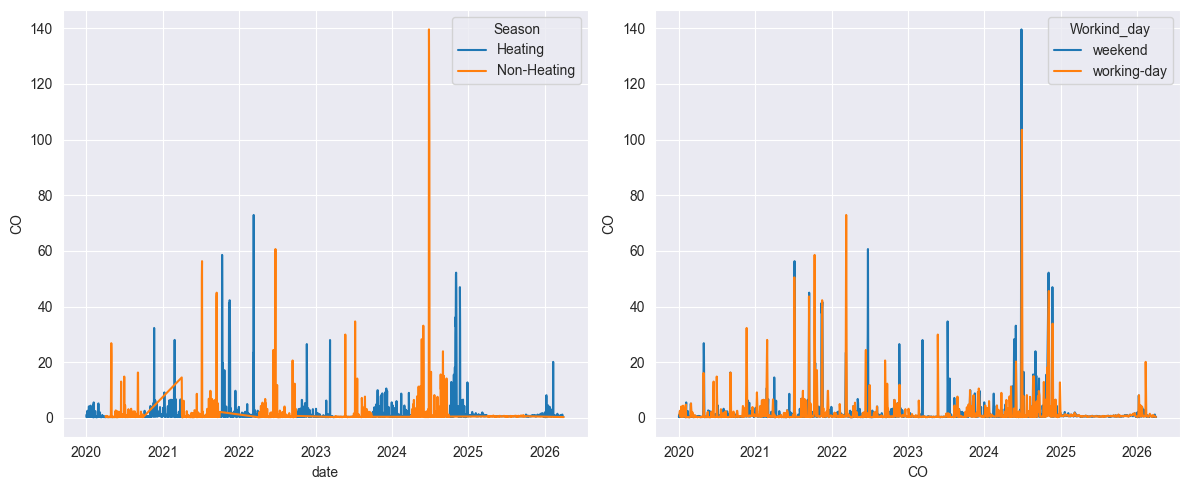

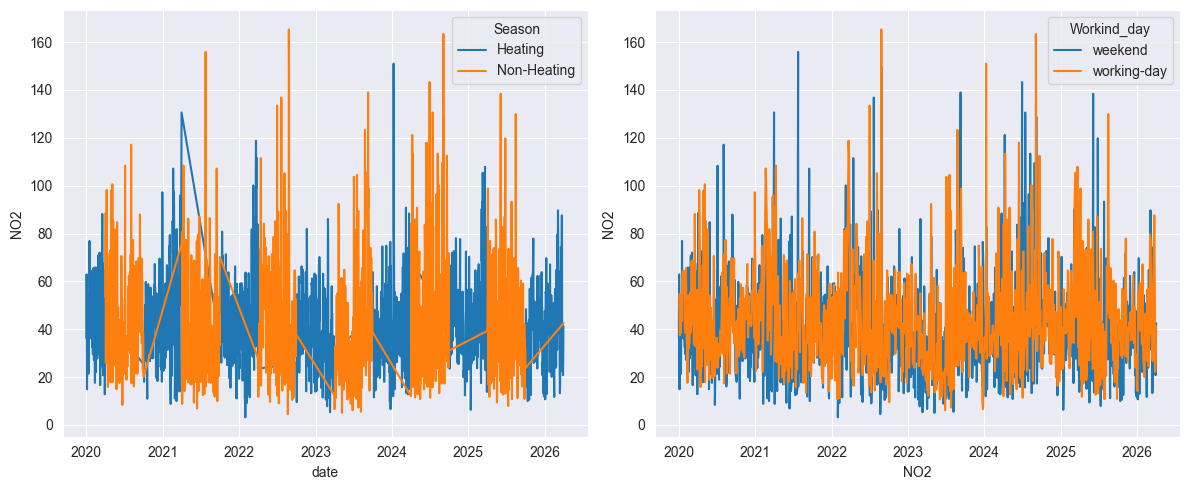

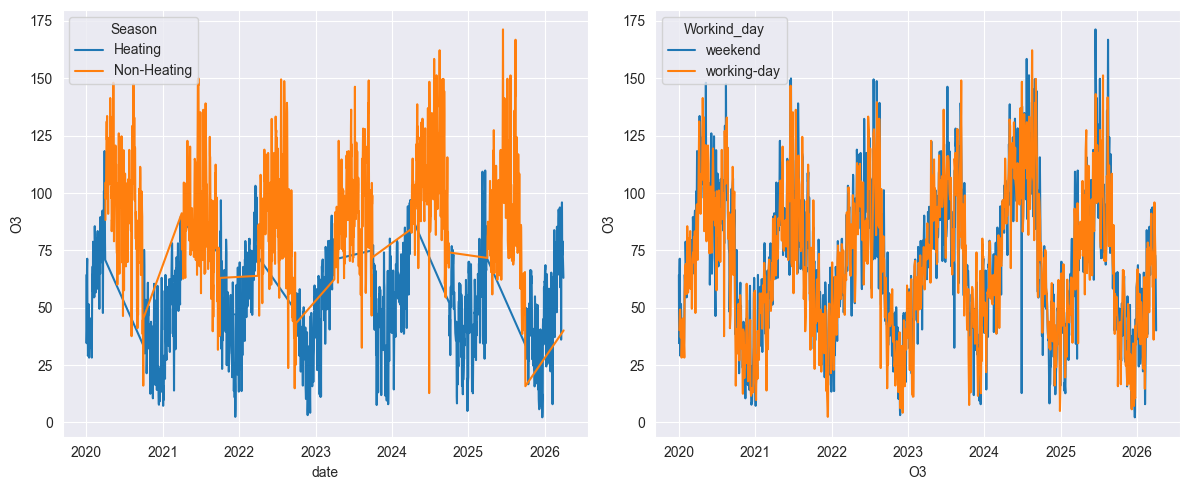

In [71]:
for i, col in enumerate(num_cols):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    sns.lineplot(data=df, x='date', y=col, ax=axes[0], hue=df['Season'])
    sns.lineplot(data=df, x='date', y=col, ax=axes[1], hue=df['Workind_day'])
    plt.xlabel(f'{col}')
    # plt.ylabel('Month')
    plt.tight_layout()
    plt.show()

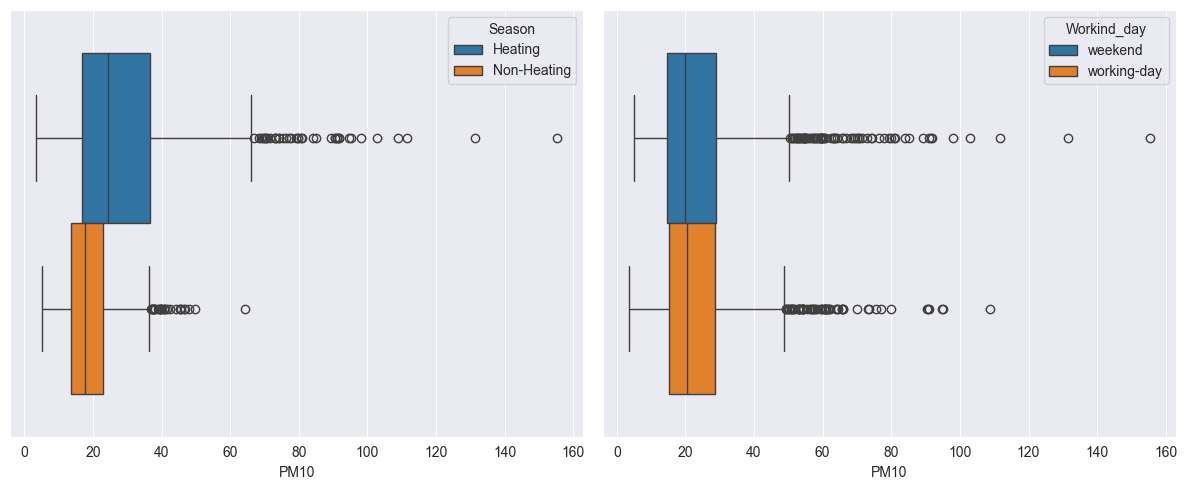

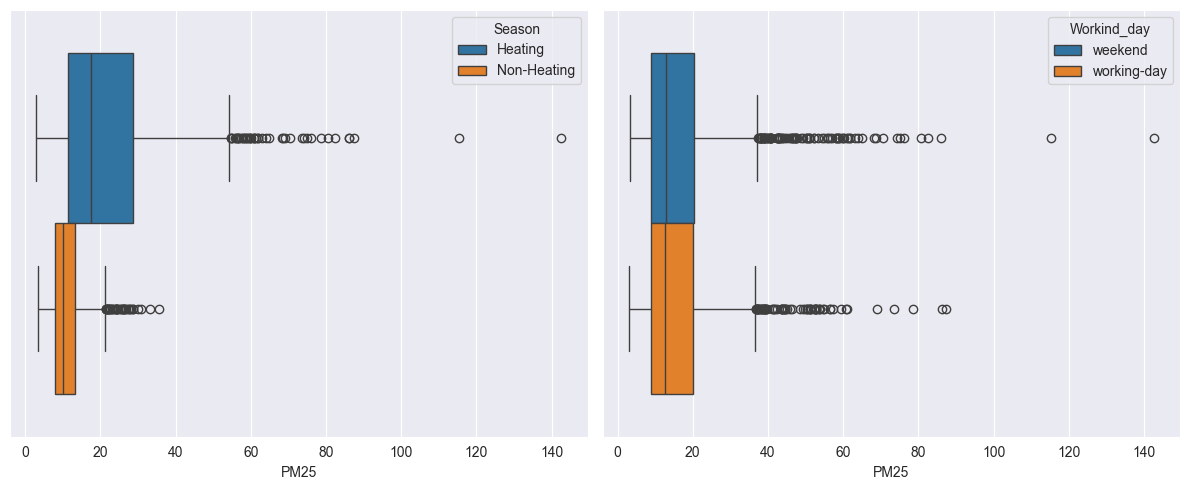

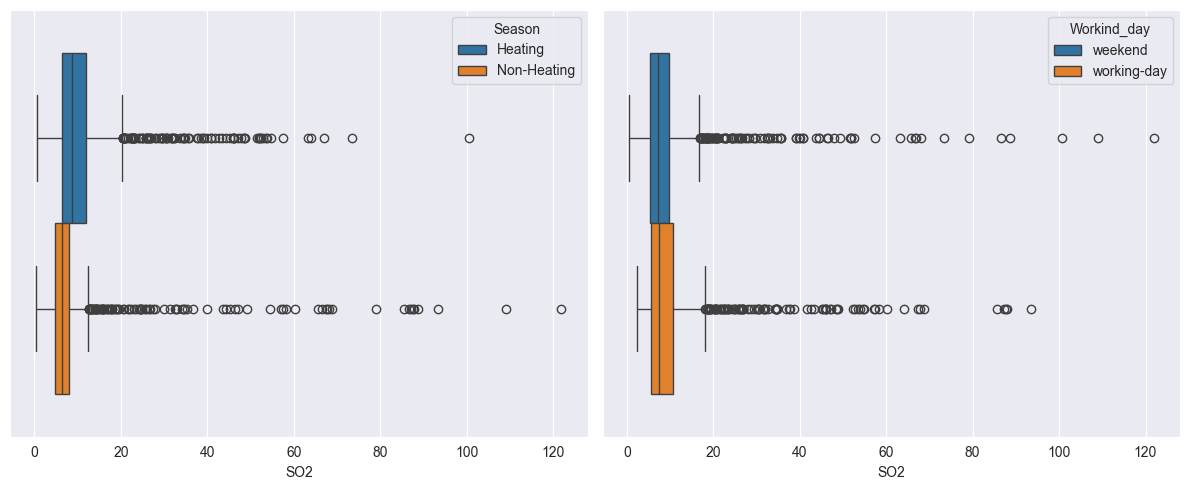

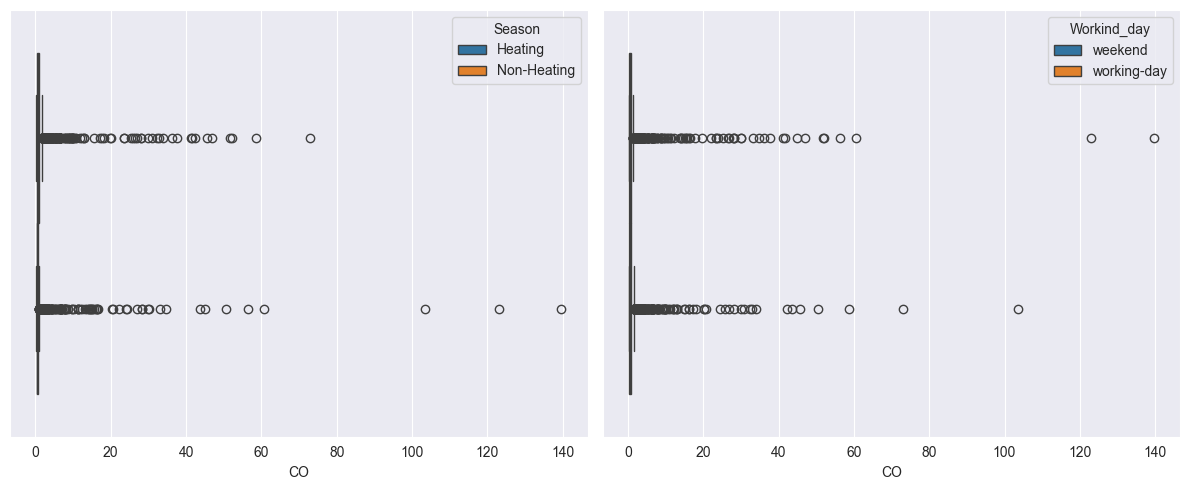

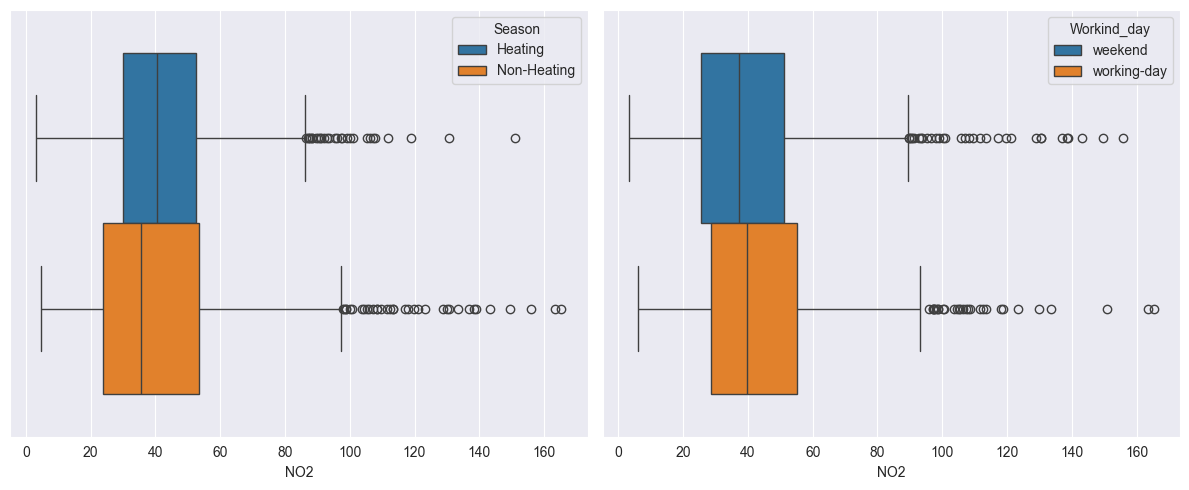

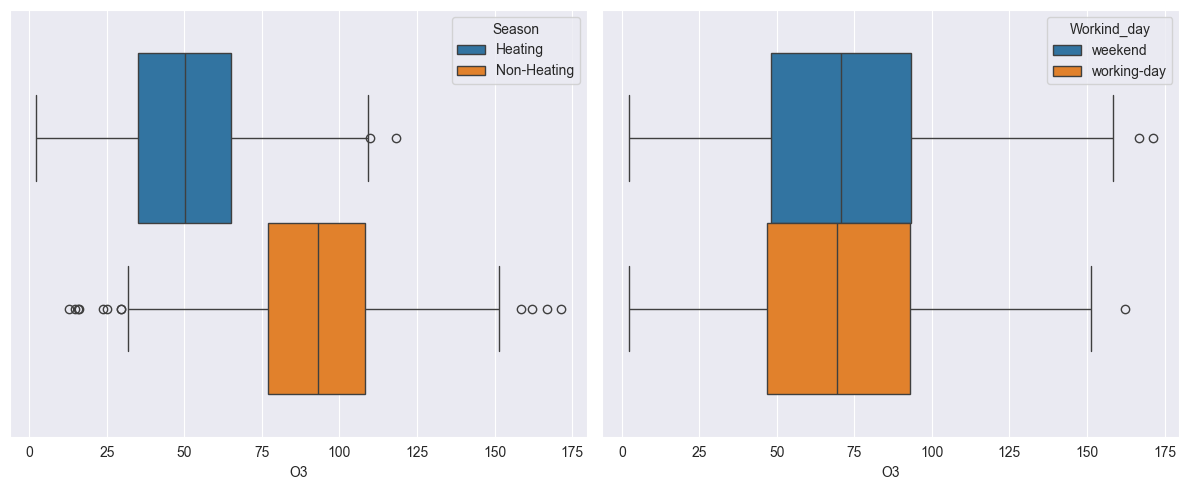

In [72]:
for i, col in enumerate(num_cols):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    sns.boxplot(data=df, x=col, hue=df['Season'], ax=axes[0])
    sns.boxplot(data=df, x=col, hue=df['Workind_day'], ax=axes[1])
    plt.xlabel(f'{col}')
    # plt.ylabel('Month')
    plt.tight_layout()
    plt.show()

In [73]:
df.groupby('Season')[numeric_cols].describe().T


Season          Heating  Non-Heating
PM10 count  1184.000000  1099.000000
     mean     28.794725    19.048066
     std      17.456263     7.339879
     min       3.430000     5.210000
     25%      16.715000    13.710000
     50%      24.250000    17.780000
     75%      36.687500    22.960000
     max     155.330000    64.280000
PM25 count  1184.000000  1099.000000
     mean     22.020053    11.134929
     std      14.841866     4.697592
     min       2.970000     3.410000
     25%      11.457500     7.950000
     50%      17.495000    10.120000
     75%      28.685000    13.305000
     max     142.570000    35.730000
SO2  count  1184.000000  1099.000000
     mean     11.074784     8.681409
     std       9.139426    11.180802
     min       0.510000     0.420000
     25%       6.300000     4.820000
     50%       8.600000     6.280000
     75%      11.900000     7.900000
     max     100.600000   121.900000
CO   count  1184.000000  1099.000000
     mean      1.976317     1.851650
     std       5.755713     7.971552
     min       0.210000     0.210000
     25%       0.430000     0.350000
     50%       0.600000     0.410000
     75%       0.960000     0.590000
     max      72.930000   139.620000
NO2  count  1184.000000  1099.000000
     mean     42.285762    41.166375
     std      18.279118    23.958522
     min       3.190000     4.520000
     25%      29.863750    23.725000
     50%      40.370000    35.620000
     75%      52.400000    53.360000
     max     151.000000   165.310000
O3   count  1184.000000  1099.000000
     mean     49.934983    93.050167
     std      20.968569    24.021644
     min       2.240000    12.800000
     25%      35.152500    76.880000
     50%      50.100000    93.000000
     75%      64.892500   108.085000
     max     118.280000   171.300000

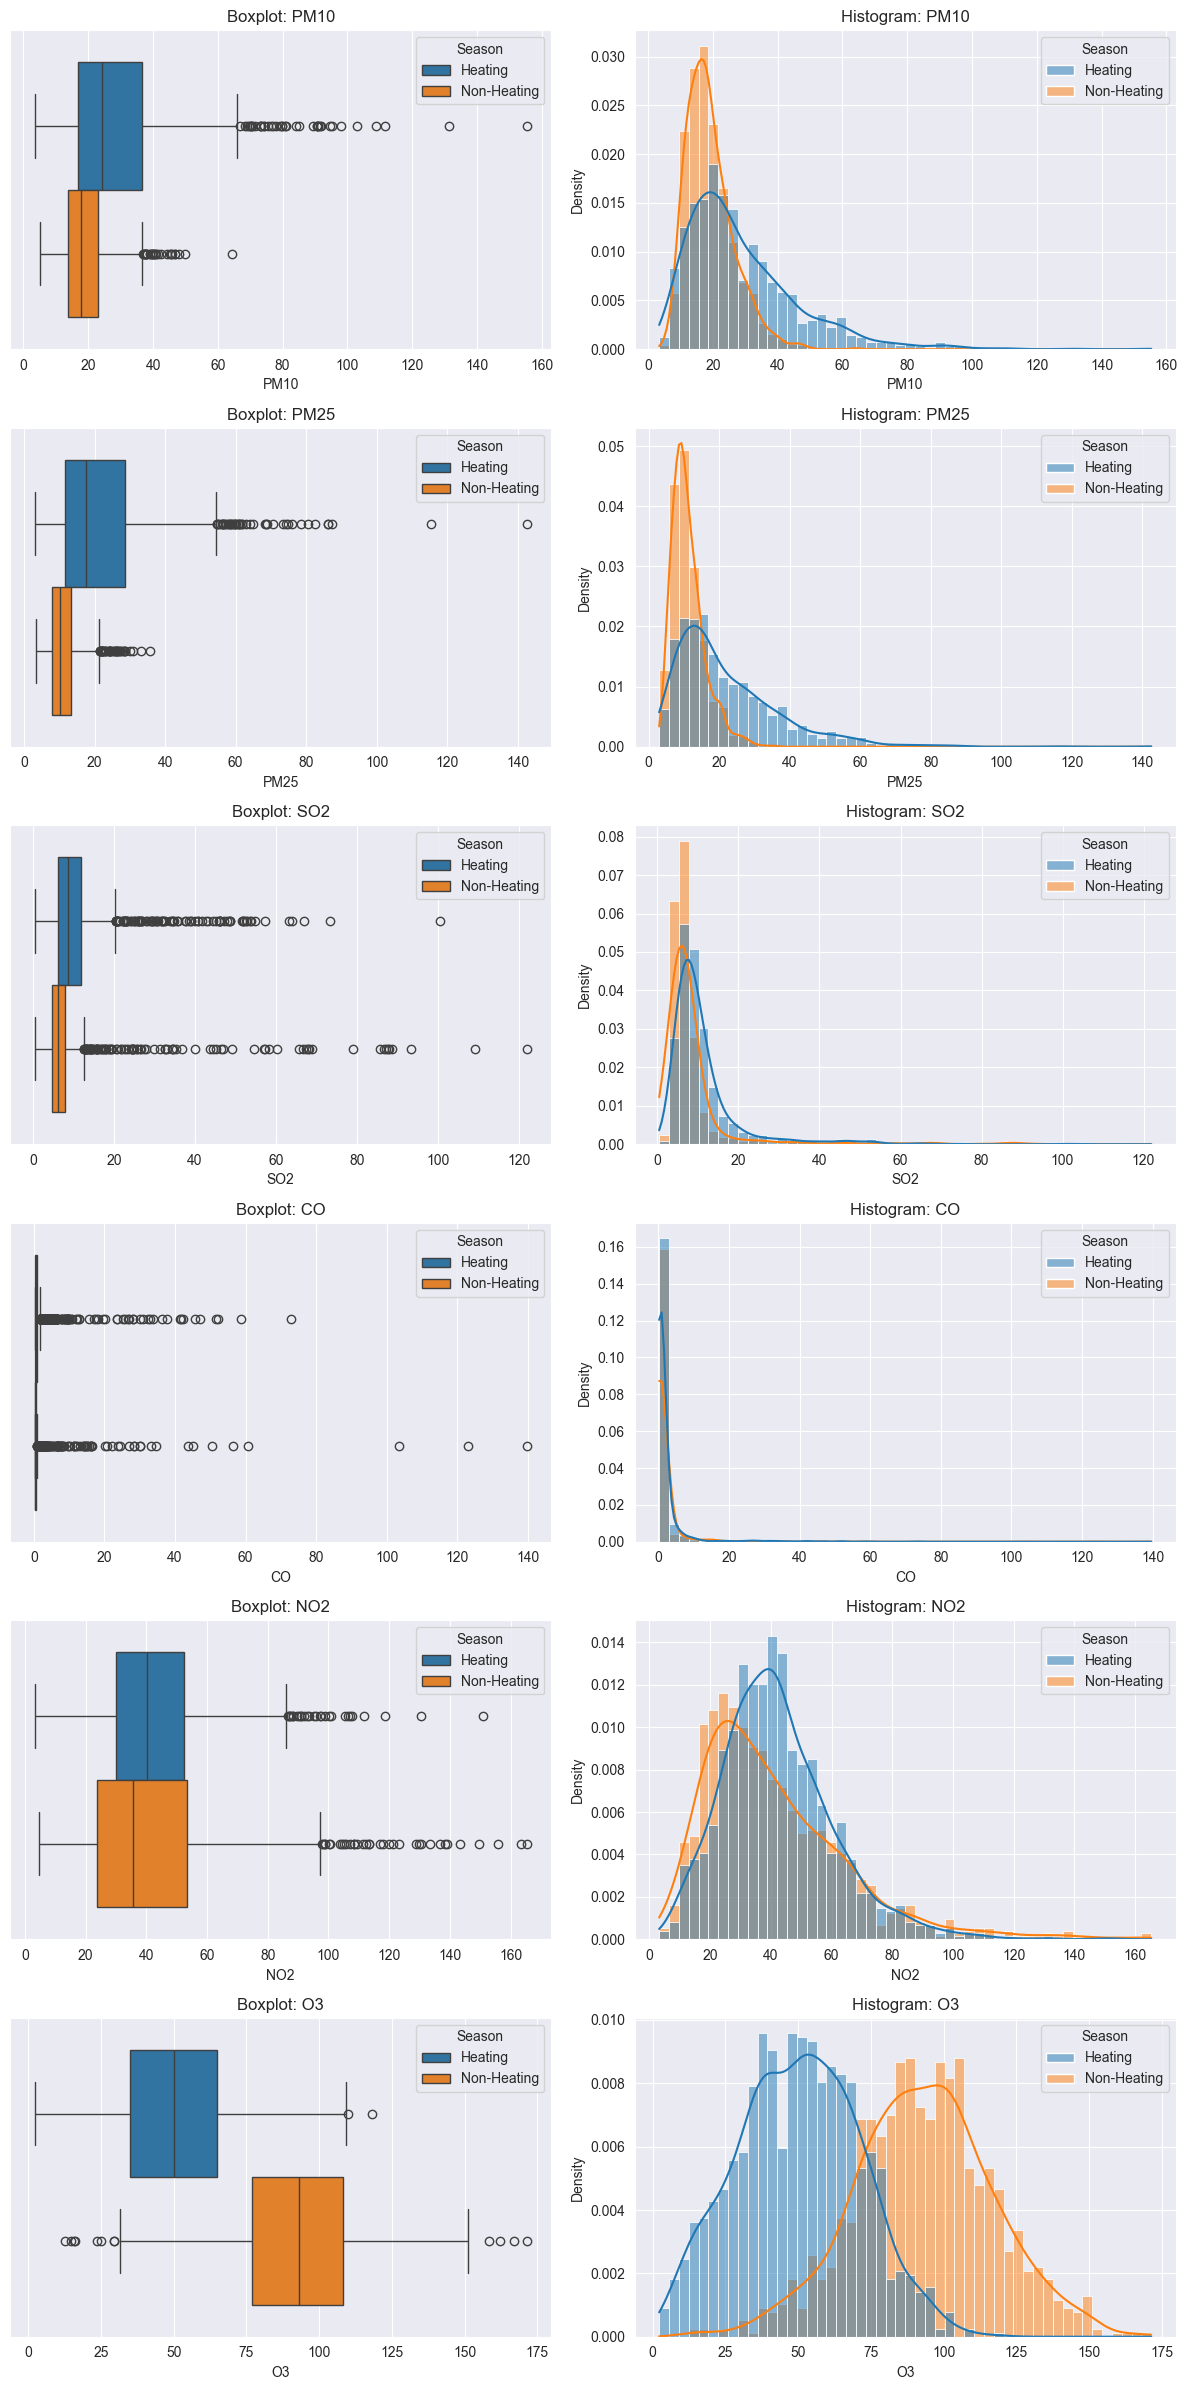

In [74]:
fig, axes = plt.subplots(nrows=n_cols, ncols=2, figsize=(12, 4 * n_cols))

for i, col in enumerate(numeric_cols):
    
    sns.boxplot(x=df[col], ax=axes[i][0], hue=df['Season'])
    axes[i][0].set_title(f'Boxplot: {col}')
    
    sns.histplot(data=df, x=col, ax=axes[i][1], kde=True, bins=50, stat="density", hue=df['Season'])
    axes[i][1].set_title(f'Histogram: {col}')

plt.tight_layout()
plt.show()

# MIESIACE DO SARIMY
SPRAWDZIC CZY JAK DODAM TEMPERATURE CZY BEDZIE POTRZEBNA SEZONOWOSC, CZYLI ARIMAX

In [ ]:
df_heating = df[df['Season'] == 'Heating']
df_non_heating = df[df['Season'] == 'Non-Heating']

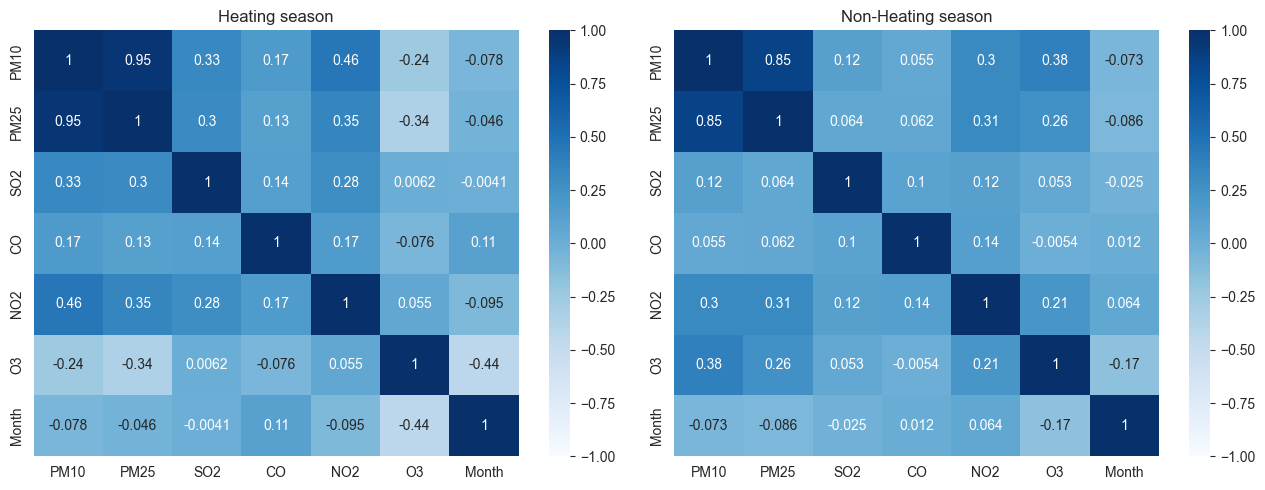

2026-04-08 13:06:15,587 - ERROR    - Exception occurred while processing request: This function does not handle missing values
Traceback (most recent call last):
  File "c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\dtale\views.py", line 120, in _handle_exceptions
    return func(*args, **kwargs)
  File "c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\dtale\views.py", line 4381, in get_timeseries_analysis
    data = ts_rpt.run()
  File "c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\dtale\timeseries_analysis.py", line 48, in run
    return self.report.run(data)
  File "c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\dtale\timeseries_analysis.py", line 110, in run
    sd_df = seasonal_decompose(df, model=model)
  File "c:\Users\aleks\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\seasonal.py", line 154, in seasonal_decompose
    raise ValueError("This functio

In [ ]:
corr_heating = df_heating.corr(numeric_only=True)
corr_non_heating = df_non_heating.corr(numeric_only=True)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))

sns.heatmap(corr_heating, annot=True, vmin=-1, vmax=1, cmap="Blues", center=0, ax=ax[0])
ax[0].set_title('Heating season')

sns.heatmap(corr_non_heating, annot=True, vmin=-1, vmax=1, cmap="Blues", center=0, ax=ax[1])
ax[1].set_title('Non-Heating season')

plt.tight_layout()
plt.show()

istotność korelacji

okresowosc, w sarimie, sinusy, albo arime grzewczy nie grzewczy, popatrzec tygodniowo